In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import scipy.signal as signal

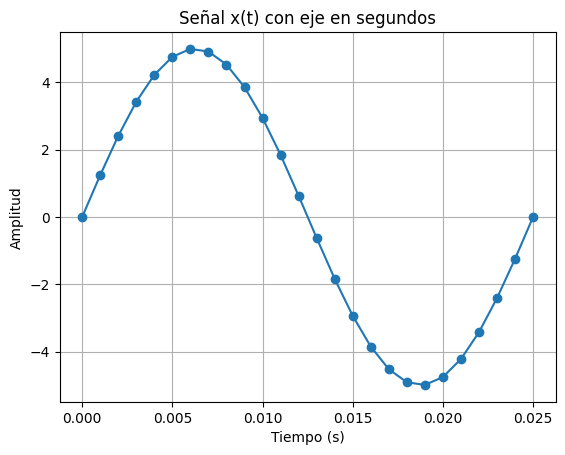

In [2]:
Fo = 40              # Frecuencia fundamental de la señal (Hz)
Tp = 1/Fo            # Periodo de la señal (s)

Fs = 1000            # Frecuencia de muestreo (Hz)
T = 1/Fs             # Periodo de muestreo (s)

t = np.arange(0, Tp+T, T)   # Tiempo para un ciclo de la señal + una muestra
A = 5                       # Amplitud

x = A*np.sin(2*np.pi*Fo*t)

plt.plot(t, x, marker='o')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal x(t) con eje en segundos')
plt.grid(True)
plt.show()

Una manera alternativa de crear la señal $x[n]$ sería usando la frecuencia normalizada $f_0 = F_0/F_s$ y el índice de muestra $n$ como eje horizontal [2]:

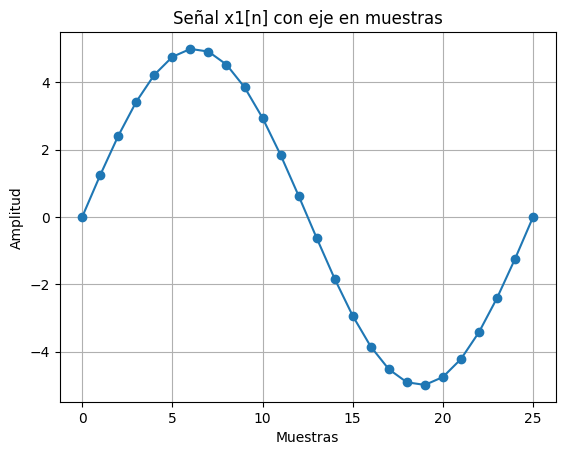

In [3]:
fo = Fo/Fs                  # Frecuencia normalizada
n = np.arange(0, len(t))    # Índices de muestra
x1 = A*np.sin(2*np.pi*fo*n)

plt.plot(n, x1, marker='o')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.title('Señal x1[n] con eje en muestras')
plt.grid(True)
plt.show()  

### A) Compruebe que los valores de las primeras cinco muestras son los mismos

In [4]:
print("Valores de las primeras cinco muestras:")
print("x(t): ", x[:5])
print("x1(n):", x1[:5])

Valores de las primeras cinco muestras:
x(t):  [0.         1.24344944 2.40876837 3.42273553 4.22163963]
x1(n): [0.         1.24344944 2.40876837 3.42273553 4.22163963]


Los valores de las primeras 5 muestras coinciden porque $x(t)$ y $x_1[n]$ son matemáticamente la misma señal, expresada de dos maneras equivalentes.

Partiendo de $x(t) = A\sin(2\pi F_0 t)$ y evaluándola en los instantes de muestreo $t = nT = n/F_s$, se obtiene [1]:

$$x[n] = A\sin\left(2\pi F_0 \cdot \frac{n}{F_s}\right) = A\sin\left(2\pi \cdot \frac{F_0}{F_s} \cdot n\right) = A\sin(2\pi f_0 n)$$

donde $f_0 = F_0/F_s$ es la frecuencia normalizada (en ciclos por muestra). Esta es justamente la expresión usada para construir $x_1[n]$, por lo que internamente se calcula el mismo seno con los mismos argumentos numéricos.

La única diferencia entre ambas representaciones está en el eje horizontal: en $x(t)$ el eje es **tiempo continuo en segundos** ($t = 0,\ 0.001,\ 0.002,\ \ldots$), mientras que en $x_1[n]$ el eje es el **índice discreto de muestra** ($n = 0,\ 1,\ 2,\ \ldots$). Por eso los valores de amplitud son idénticos: no son dos señales distintas, sino la misma señal vista en dos dominios temporales equivalentes.

### Visualización con la función `stem`

Otra manera de graficar las señales muestreadas es mediante la función `stem`, que dibuja cada muestra como un palito vertical con un punto en el extremo, resaltando el carácter discreto de la señal.

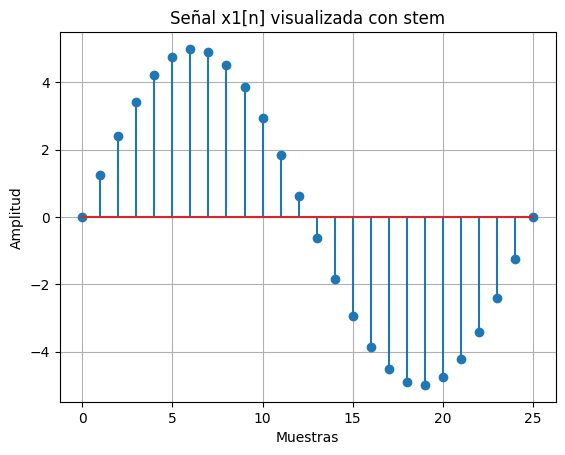

In [5]:
plt.stem(n, x1)
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.title('Señal x1[n] visualizada con stem')
plt.grid(True)
plt.show()

### Energía y potencia en el dominio del tiempo

La **energía** de un ciclo de la señal $x[n]$ (medida en $V^2$ o $W\cdot s$) se calcula como la suma de las muestras al cuadrado[3]:

$$E = \sum_{n=0}^{N-1} x[n]^2$$

La **potencia media** (en W) es la energía dividida entre el número de muestras[4]:

$$P = \frac{E}{N}$$

El **valor cuadrático medio (RMS)** es la raíz cuadrada de la potencia[5]:

$$x_{rms} = \sqrt{P}$$

In [7]:
energia = sum(x**2)
potencia = energia/(len(t)-1)
rms = np.sqrt(potencia)

print("--- Un ciclo ---")
print("Energía:", energia)
print("Potencia:", potencia)
print("RMS:", rms)

--- Un ciclo ---
Energía: 312.50000000000006
Potencia: 12.500000000000002
RMS: 3.5355339059327378


Ahora calculamos los mismos parámetros considerando **10 ciclos** de la señal (duración de 250 ms):

In [8]:
t10 = np.arange(0, 10*Tp+T, T)
x10 = A*np.sin(2*np.pi*Fo*t10)

energia10 = sum(x10**2)
potencia10 = energia10/(len(t10)-1)
rms10 = np.sqrt(potencia10)

print("--- 10 ciclos ---")
print("Energía:", energia10)
print("Potencia:", potencia10)
print("RMS:", rms10)

--- 10 ciclos ---
Energía: 3125.0000000000014
Potencia: 12.500000000000005
RMS: 3.535533905932738


### B) La potencia es la misma que en $x[n]$. ¿Por qué?

La potencia media calculada para 1 ciclo y para 10 ciclos da prácticamente el mismo valor porque $x[n]$ es una **señal periódica**: su forma de onda se repite de manera idéntica en cada periodo.

La energía sí cambia: al considerar 10 ciclos, la suma $\sum x[n]^2$ es aproximadamente 10 veces mayor que la de un solo ciclo, porque se están sumando 10 veces los mismos valores al cuadrado. Sin embargo, al calcular la **potencia media** se divide esa energía entre el número total de muestras (que también es 
aproximadamente 10 veces mayor):

$$P_{10} = \frac{E_{10}}{N_{10}} \approx \frac{10 \cdot E_1}{10 \cdot N_1} = \frac{E_1}{N_1} = P_1$$

Es decir, el factor 10 se cancela en el cociente. La potencia media de una señal periódica es una propiedad **intrínseca de la forma de onda**, no de cuántos ciclos se observen. Por la misma razón, el valor RMS también coincide en ambos casos. Para una señal senoidal de amplitud $A$, el valor teórico es $x_{rms} = A/\sqrt{2} = 5/\sqrt{2} \approx 3.536$, que es justamente el resultado que obtenemos numéricamente.

### Análisis de Fourier en tiempo discreto

La **Transformada Discreta de Fourier (DFT)** de una señal $x[n]$ se calcula en Python mediante `np.fft.fft`. Internamente utiliza el algoritmo FFT (*Fast Fourier Transform*), que es una versión computacionalmente eficiente. Calculemos la DFT de la señal de 10 ciclos $x_{10}[n]$:

In [9]:
X10 = np.fft.fft(x10)

print("Número de muestras de x10:", len(x10))
print("Número de coeficientes de la DFT:", len(X10))

Número de muestras de x10: 251
Número de coeficientes de la DFT: 251


La DFT tiene el mismo número de puntos que la señal de entrada. Como $x_{10}[n]$ toma valores reales únicamente, su DFT presenta simetría circularmente par en el módulo. Visualicemos primero el módulo de la DFT con el eje en muestras:

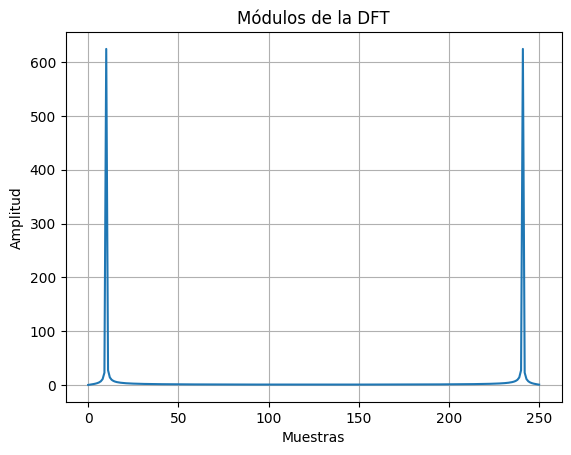

In [10]:
plt.plot(abs(X10))
plt.title('Módulos de la DFT')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

Se observan dos picos simétricos con valor máximo cercano a 625. Este valor no es casual: la DFT $X[k]$ está relacionada con los coeficientes $c_k$ de la serie de Fourier mediante $X[k] = N \cdot c_k$. Para una senoidal de amplitud $A$, el coeficiente asociado a la frecuencia de oscilación tiene módulo $A/2$. Por lo tanto, en la frecuencia fundamental:

$$|X[k]| = N \cdot \frac{A}{2} = 250 \cdot \frac{5}{2} = 625$$

Para interpretar la DFT en términos de frecuencia continua $F$ (en Hz), escalamos los índices $k$ usando la relación $F = k \cdot F_s / N$:

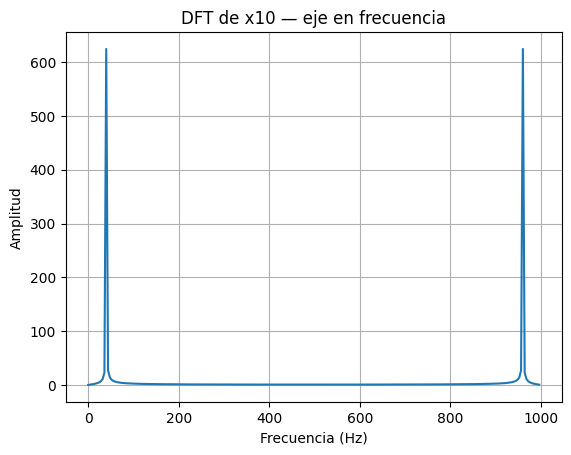

In [11]:
N = len(X10)
F = np.arange(0, N)*Fs/N

plt.plot(F, abs(X10))
plt.title('DFT de x10 — eje en frecuencia')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

Habitualmente solo se grafica **la mitad de los puntos**, hasta la mitad de $F_s$ (llamada **frecuencia de Nyquist**), ya que la otra mitad se deduce por simetría:

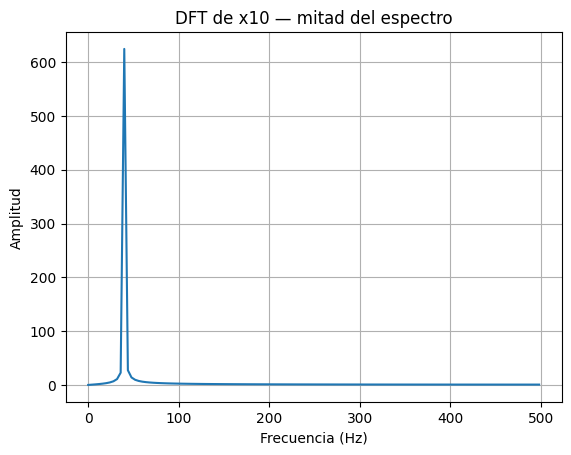

In [12]:
Nmitad = int(np.ceil(N/2))
Fmitad = np.arange(0, Nmitad)*Fs/N
X10mitad = X10[0:Nmitad]

plt.plot(Fmitad, abs(X10mitad))
plt.title('DFT de x10 — mitad del espectro')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

Haciendo un *zoom* en las frecuencias bajas, se observa con claridad que la componente frecuencial está ubicada exactamente en **40 Hz**, que es la frecuencia fundamental de la señal:

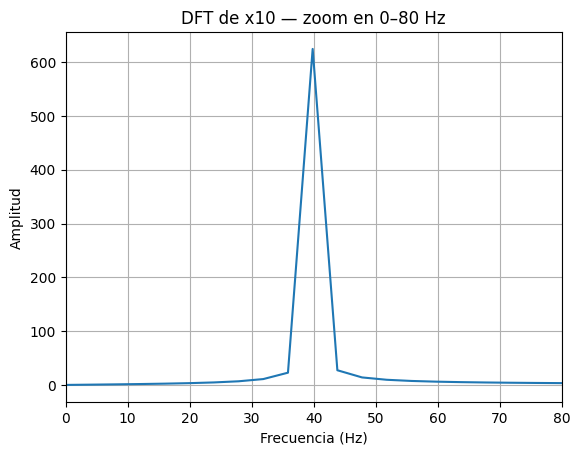

In [13]:
plt.plot(Fmitad, abs(X10mitad))
plt.title('DFT de x10 — zoom en 0–80 Hz')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.xlim(0, 80)
plt.grid(True)
plt.show()

## Periodogramas

El análisis frecuencial de señales discretas también puede realizarse mediante **periodogramas**, que estiman el contenido de potencia de las distintas frecuencias a partir de la DFT aplicada sobre una ventana corta de la señal. Si la ventana es **rectangular** se habla de periodograma; si es de otro tipo (Hanning, Hamming, etc.), de periodograma modificado.

### Método de Welch

Estimar la frecuencia de una señal larga con una sola ventana corta puede no reflejar bien su comportamiento global. Como alternativa, el **método de Welch** divide la señal en varios segmentos solapados, aplica una ventana a cada uno, calcula su densidad espectral de potencia y **promedia los resultados**, obteniendo una estimación más estable y menos ruidosa de la PSD.

En Python se implementa con `scipy.signal.welch`, cuyos parámetros principales son:

- `fs`: frecuencia de muestreo.
- `window`: tipo de ventana (`'hann'`, `'hamming'`, etc.).
- `nperseg`: número de muestras por segmento (ancho de la ventana).
- `noverlap`: muestras de solapamiento entre segmentos.

### Ejemplo

Aplicamos Welch a la señal senoidal de 40 Hz construida previamente (10 ciclos, $F_s = 1000$ Hz), usando ventana Hanning de 64 muestras y solapamiento del 50%.

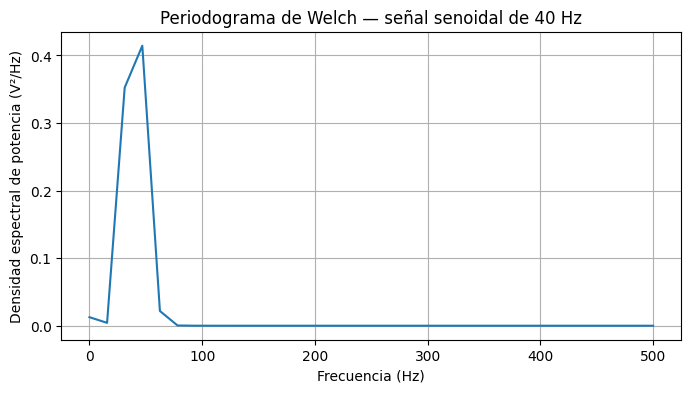

In [14]:
from scipy.signal import welch

nperseg = 64                  # Ancho de la ventana (muestras)
noverlap = nperseg // 2       # Solapamiento del 50%

f_welch, Pxx = welch(x10, fs=Fs, window='hann',
                     nperseg=nperseg, noverlap=noverlap)

plt.figure(figsize=(8, 4))
plt.plot(f_welch, Pxx)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia (V²/Hz)')
plt.title('Periodograma de Welch — señal senoidal de 40 Hz')
plt.grid(True)
plt.show()

El periodograma de Welch muestra un **único pico bien definido en 40 Hz**, que corresponde a la frecuencia fundamental de la señal senoidal. La densidad espectral de potencia es prácticamente nula en el resto de las frecuencias, lo cual es coherente con que se trata de una señal sinusoidal pura.

Esta misma técnica se aplicará más adelante a señales fisiológicas reales (ECG y EEG), donde la elección del ancho de ventana y del solapamiento será crucial para obtener una buena resolución frecuencial.

## APLICACIÓN

### 4.1 — Señal suma de tres componentes sinusoidales

> Cree una señal que sea la suma de tres componentes sinusoidales con frecuencias 
> de 40, 80 y 160 Hz. Defina la frecuencia de muestreo mínima necesaria para 
> representar la señal, y utilice la frecuencia de muestreo necesaria para 
> representarla apropiadamente.

La señal a construir es:

$$x(t) = A\sin(2\pi \cdot 40\, t) + A\sin(2\pi \cdot 80\, t) + A\sin(2\pi \cdot 160\, t)$$

Frecuencia de muestreo mínima (Teorema de Nyquist): El teorema de Nyquist-Shannon establece que, para reconstruir sin pérdida una señal con componentes de frecuencia máxima $F_{max}$, la frecuencia de muestreo debe cumplir:

$$F_s > 2 \cdot F_{max}$$

En este caso, la componente de mayor frecuencia es **160 Hz**, por lo tanto la frecuencia de muestreo mínima teórica es:

$$F_{s,\text{min}} > 2 \cdot 160 = 320 \text{ Hz}$$

Frecuencia de muestreo elegida: Aunque 320 Hz cumple teóricamente con Nyquist, en la práctica se utiliza una frecuencia bastante mayor para obtener una **representación visual suave** y un margen de seguridad. Se eligió:

$$F_s = 1000 \text{ Hz}$$

es decir, **más de 6 veces** la frecuencia máxima de la señal. Las tres componentes se muestrean con la **misma $F_s$** para que compartan el mismo eje temporal y puedan sumarse correctamente.

El periodo fundamental de la señal compuesta corresponde a la frecuencia más baja ($F_0 = 40$ Hz, ya que 80 y 160 son múltiplos enteros de 40), por lo que la señal completa se repite cada $T_p = 1/40 = 0.025$ s.

Frecuencia máxima de la señal: 160 Hz
Frecuencia de muestreo mínima (Nyquist): 320 Hz


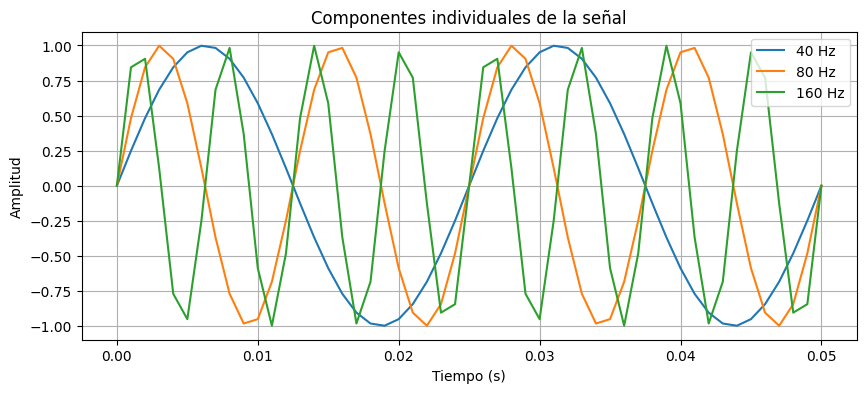

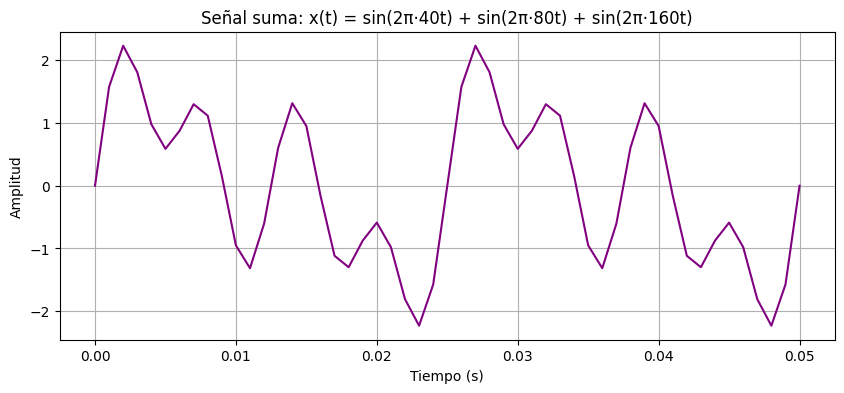

In [15]:
# Frecuencias de las componentes
F1 = 40
F2 = 80
F3 = 160

Fmax = max(F1, F2, F3)
Fs_min = 2*Fmax
print("Frecuencia máxima de la señal:", Fmax, "Hz")
print("Frecuencia de muestreo mínima (Nyquist):", Fs_min, "Hz")

# Frecuencia de muestreo elegida
Fs = 1000
T = 1/Fs

# Tomamos 2 periodos del fundamental para que se aprecie bien
Tp = 1/F1
t = np.arange(0, 2*Tp+T, T)

A = 1
x1 = A*np.sin(2*np.pi*F1*t)
x2 = A*np.sin(2*np.pi*F2*t)
x3 = A*np.sin(2*np.pi*F3*t)

x_suma = x1 + x2 + x3

# Gráfica de las componentes individuales
plt.figure(figsize=(10, 4))
plt.plot(t, x1, label='40 Hz')
plt.plot(t, x2, label='80 Hz')
plt.plot(t, x3, label='160 Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Componentes individuales de la señal')
plt.legend()
plt.grid(True)
plt.show()

# Gráfica de la señal suma
plt.figure(figsize=(10, 4))
plt.plot(t, x_suma, color='purple')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal suma: x(t) = sin(2π·40t) + sin(2π·80t) + sin(2π·160t)')
plt.grid(True)
plt.show()

### Punto 4.2 — Transformada de Fourier de la señal suma

> Calcule la transformada de Fourier de la señal y grafique el espectro de 
> frecuencia. Identifique en el espectro las frecuencias que componen la señal 
> (trabaje con 10 periodos de la señal).

Para que el espectro tenga buena resolución frecuencial, trabajamos con 10 periodos del fundamental ($T_p = 1/40 = 0.025$ s), lo que da una duración total de $10 \cdot T_p = 0.25$ s.

La resolución frecuencial de la DFT viene dada por [6]:

$$\Delta F = \frac{F_s}{N}$$

donde $N$ es el número total de muestras. Con $F_s = 1000$ Hz y $N = 250$ muestras, la resolución es $\Delta F = 1000/250 = 4$ Hz, lo cual permite distinguir claramente las componentes de 40, 80 y 160 Hz.

Se grafica únicamente la mitad del espectro (hasta la frecuencia de Nyquist $F_s/2 = 500$ Hz), ya que la otra mitad es simétrica al tratarse de una señal real.

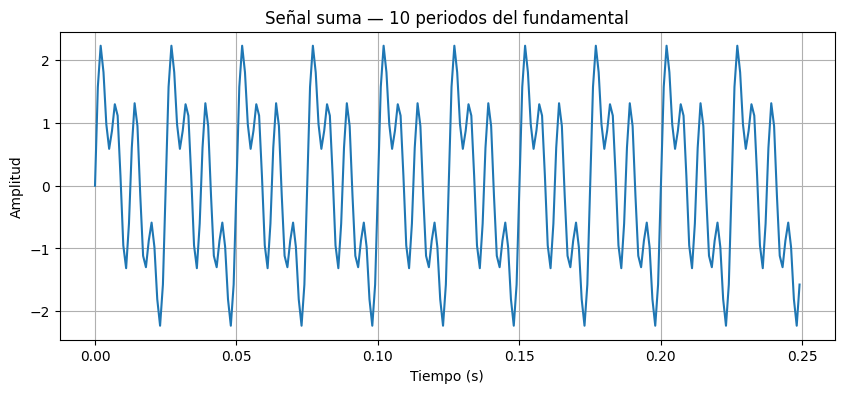

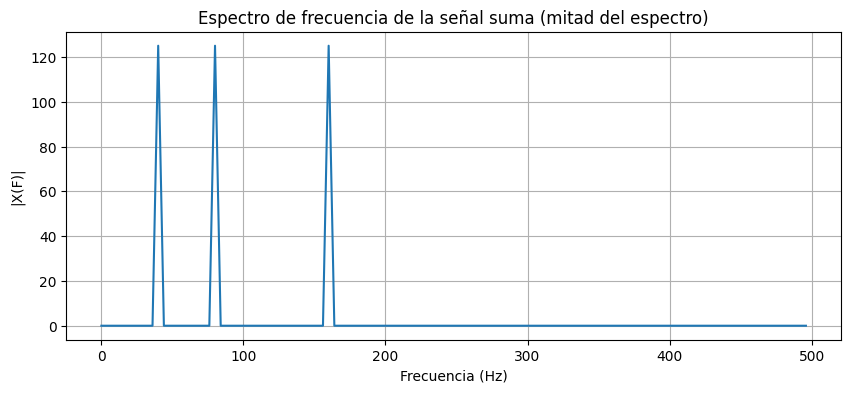

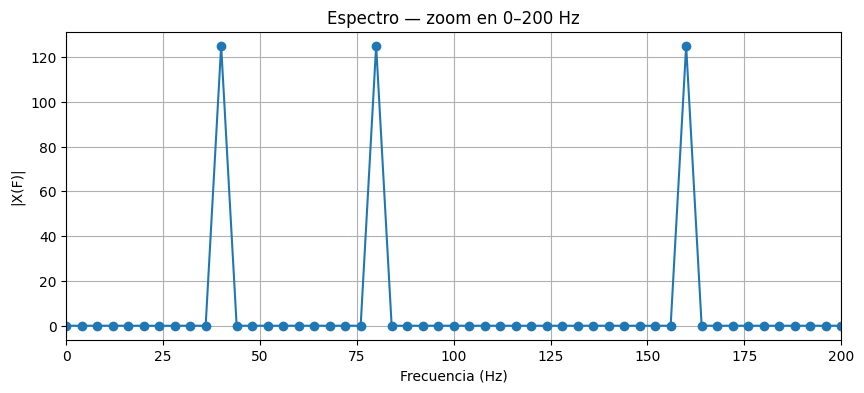

In [16]:
# Señal suma con 10 periodos del fundamental
Tp = 1/F1                           # Periodo fundamental (1/40 s)
t10 = np.arange(0, 10*Tp, T)        # 10 periodos, mismo Fs del Punto 1
A = 1

x1_10 = A*np.sin(2*np.pi*F1*t10)
x2_10 = A*np.sin(2*np.pi*F2*t10)
x3_10 = A*np.sin(2*np.pi*F3*t10)

x_suma_10 = x1_10 + x2_10 + x3_10

# Gráfica de la señal en el tiempo
plt.figure(figsize=(10, 4))
plt.plot(t10, x_suma_10)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal suma — 10 periodos del fundamental')
plt.grid(True)
plt.show()

# Cálculo de la FFT
X_suma = np.fft.fft(x_suma_10)
N = len(X_suma)

# Vector de frecuencias en Hz
F_eje = np.arange(0, N)*Fs/N

# Mitad del espectro (hasta Nyquist)
Nmitad = int(np.ceil(N/2))
F_mitad = F_eje[0:Nmitad]
X_mitad = X_suma[0:Nmitad]

# Gráfica del espectro
plt.figure(figsize=(10, 4))
plt.plot(F_mitad, abs(X_mitad))
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('|X(F)|')
plt.title('Espectro de frecuencia de la señal suma (mitad del espectro)')
plt.grid(True)
plt.show()

# Zoom en 0–200 Hz para identificar los picos
plt.figure(figsize=(10, 4))
plt.plot(F_mitad, abs(X_mitad), marker='o')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('|X(F)|')
plt.title('Espectro — zoom en 0–200 Hz')
plt.xlim(0, 200)
plt.grid(True)
plt.show()

### Identificación de las componentes frecuenciales

En el espectro se observan **tres picos bien definidos**, cada uno con amplitud cercana a $N \cdot A/2 = 250 \cdot 1/2 = 125$, ubicados exactamente en:

- **40 Hz** → primera componente sinusoidal
- **80 Hz** → segunda componente sinusoidal  
- **160 Hz** → tercera componente sinusoidal

Esto confirma que la señal está compuesta por las tres frecuencias propuestas. Como las tres frecuencias son múltiplos enteros de la resolución frecuencial $\Delta F = 4$ Hz, los picos aparecen como líneas verticales nítidas sin dispersión espectral. El resto del espectro es prácticamente cero, lo que verifica que la señal no contiene otras componentes frecuenciales.

### Punto 4.3 — Transformada inversa de Fourier (IFFT)

> Consulte la función que permite realizar el cálculo de la transformada inversa 
> de Fourier. Aplíquelo a la señal anterior.

La función `numpy.fft.ifft` calcula la **Transformada Discreta Inversa de Fourier** (IDFT). Si $X[k]$ es la DFT de una señal $x[n]$ de $N$ muestras, entonces [7] [8]:

$$x[n] = \frac{1}{N}\sum_{k=0}^{N-1} X[k]\, e^{j 2\pi k n / N}$$

Es decir, la IFFT reconstruye la señal original en el dominio del tiempo a partir de su representación en frecuencia. Aplicada a `X_suma` (la DFT calculada en el Punto 2), debería devolvernos exactamente la señal `x_suma_10`.

La salida de `ifft` es en general un arreglo de **números complejos** por la naturaleza del cálculo. Sin embargo, cuando la señal original es real, la parte imaginaria del resultado es del orden del error numérico de redondeo ($\sim 10^{-15}$) y puede despreciarse. Por eso se grafica únicamente la parte real mediante `np.real(...)`.

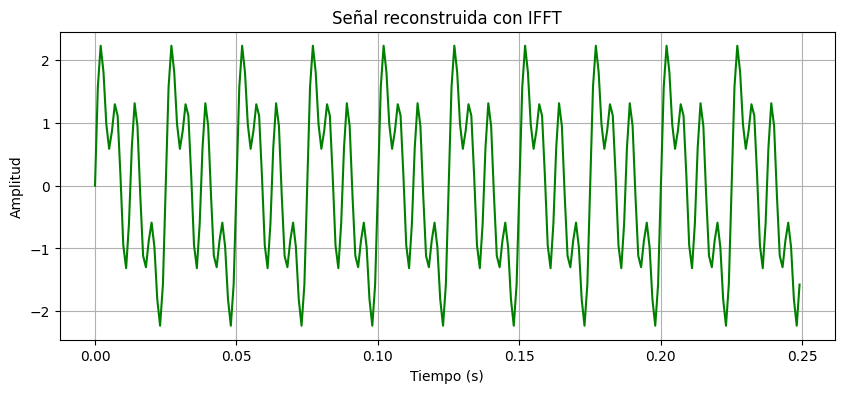

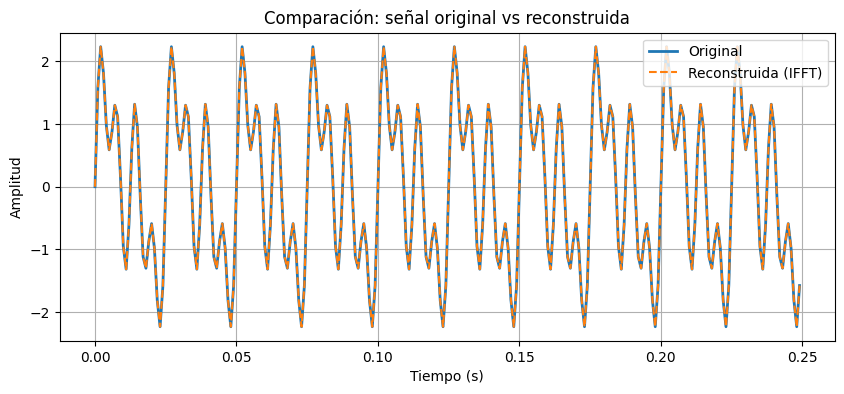

Error máximo entre original y reconstruida: 8.881784197001252e-16
Magnitud máxima de la parte imaginaria: 6.396910838331895e-16


In [17]:
# Aplicamos la IFFT al espectro calculado en el Punto 2
x_reconstruida = np.fft.ifft(X_suma)

# Gráfica de la señal reconstruida
plt.figure(figsize=(10, 4))
plt.plot(t10, np.real(x_reconstruida), color='green')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal reconstruida con IFFT')
plt.grid(True)
plt.show()

# Comparación: original vs reconstruida superpuestas
plt.figure(figsize=(10, 4))
plt.plot(t10, x_suma_10, label='Original', linewidth=2)
plt.plot(t10, np.real(x_reconstruida), '--', label='Reconstruida (IFFT)', linewidth=1.5)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Comparación: señal original vs reconstruida')
plt.legend()
plt.grid(True)
plt.show()

# Verificación numérica
error_max = np.max(np.abs(x_suma_10 - np.real(x_reconstruida)))
parte_imag_max = np.max(np.abs(np.imag(x_reconstruida)))
print("Error máximo entre original y reconstruida:", error_max)
print("Magnitud máxima de la parte imaginaria:", parte_imag_max)

### Verificación de la reconstrucción

Al superponer la señal original con la reconstruida mediante IFFT, ambas **coinciden exactamente** (las líneas se sobreponen sin diferencia apreciable). Esto se confirma numéricamente: el error máximo entre ambas y la magnitud de la parte imaginaria son del orden de $10^{-14}$, lo cual corresponde al error de redondeo propio de la aritmética de punto flotante de doble precisión, no a una pérdida de información.

Esto demuestra que la **FFT y la IFFT son operaciones inversas exactas**: la información de la señal se conserva al pasar entre el dominio del tiempo y el dominio de la frecuencia. Esta propiedad es fundamental para el filtrado en frecuencia.

### Punto 4.4 — Filtrado en frecuencia y extracción de componentes

> ¿Podría decir que las siguientes líneas aplican un filtro? ¿Por qué? Extraiga 
> de manera similar cada una de las componentes de la señal.

### Análisis del código propuesto

```python
F1 = np.fft.fft(x);
F2 = np.zeros((len(F1)));
F2[9:13] = F1[9:13];
xr = np.fft.ifft(F2);
```

Sí, estas líneas implementan un filtro, específicamente un filtro pasa-banda en el dominio de la frecuencia. La idea de manipular los coeficientes de la FFT y luego aplicar la transformada inversa para reconstruir una versión modificada de la señal es la base del filtrado espectral. El procedimiento es el siguiente:

1. **`F1 = np.fft.fft(x)`** — Se calcula la DFT de la señal, llevándola del dominio del tiempo al dominio de la frecuencia, donde cada coeficiente representa la amplitud y la fase de una frecuencia específica de la señal.
2. **`F2 = np.zeros(len(F1))`** — Se crea un arreglo del mismo tamaño que `F1` inicializado a cero. Esto equivale a un filtro que, por defecto, elimina todas las frecuencias.
3. **`F2[9:13] = F1[9:13]`** — Se copian únicamente los coeficientes de las posiciones 9, 10, 11 y 12 del espectro original. Esto significa que solo esa banda específica de frecuencias se conserva, mientras que el resto permanece en cero.
4. **`xr = np.fft.ifft(F2)`** — Se aplica la IFFT al espectro modificado, obteniendo la señal filtrada en el dominio del tiempo .

El resultado es un filtro pasa-banda ideal (de pendiente infinita, lo cual no es realizable físicamente con filtros analógicos, pero sí en procesamiento digital offline). La principal limitación de este método es que el filtro solo es estrictamente ideal cuando la señal contiene únicamente frecuencias que coinciden exactamente con los índices $k$ de la DFT; si una componente cae entre dos índices, aparece *spectral leakage* y el filtrado no es perfecto.

### Extracción de cada componente

Aplicaremos esta misma técnica para extraer por separado las componentes de 40, 80 y 160 Hz de la señal `x_suma_10`. Para ello, se calculan los índices correspondientes a cada frecuencia usando la relación:

$$k = \frac{F \cdot N}{F_s}$$

Con $N = 250$ y $F_s = 1000$ Hz, se obtienen los siguientes índices:

| Frecuencia | Índice $k$ | Índice espejo $N - k$ |
|------------|-----------|----------------------|
| 40 Hz      | 10        | 240                  |
| 80 Hz      | 20        | 230                  |
| 160 Hz     | 40        | 210                  |

Es fundamental conservar ambos índices simétricos (el positivo y su espejo) para que la IFFT devuelva una señal puramente real. Si solo se conservara uno de los dos, aparecerían componentes imaginarias significativas en la reconstrucción [9], [10], [11].

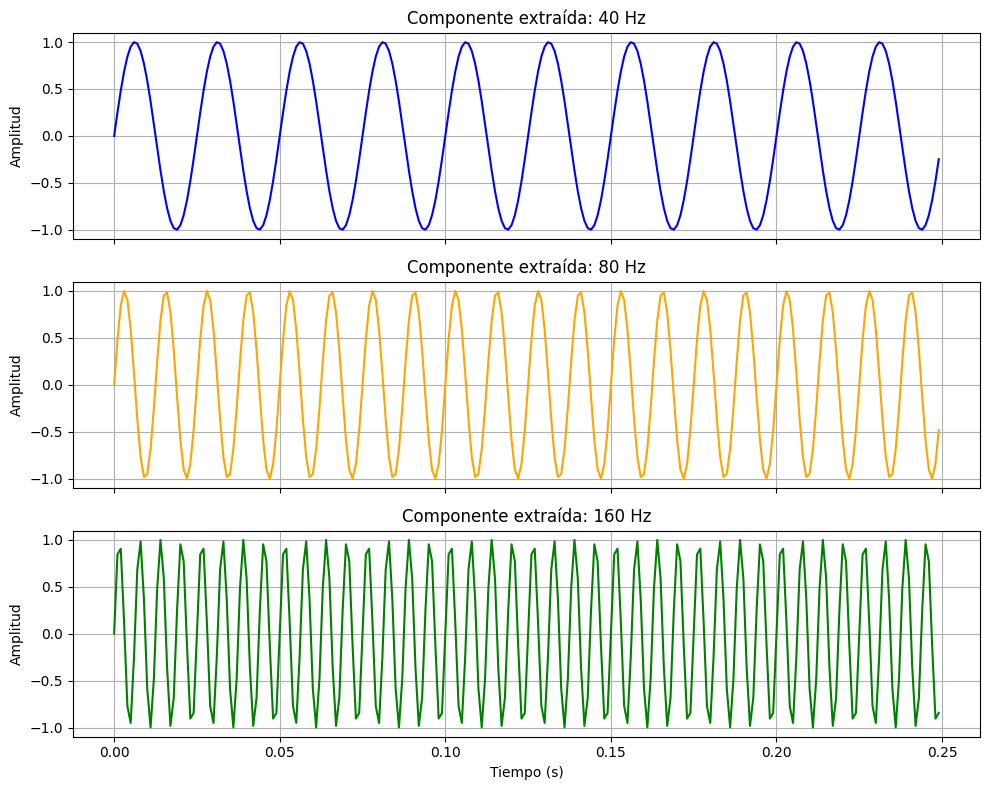

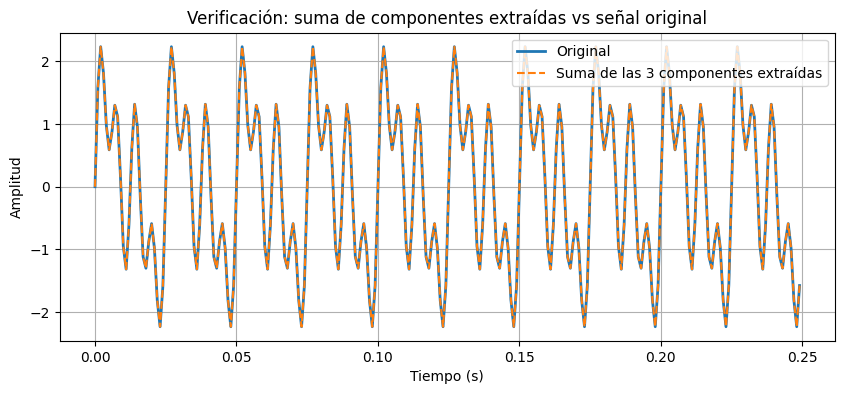

Error máximo entre la suma de componentes y la señal original: 4.1431275097515474e-14


In [18]:
N = len(X_suma)

# Función auxiliar para extraer una componente dada su frecuencia
def extraer_componente(X, F_obj, Fs, N):
    k = int(round(F_obj * N / Fs))   # Índice positivo
    F_filtrado = np.zeros(N, dtype=complex)
    F_filtrado[k] = X[k]              # Conservar coeficiente positivo
    F_filtrado[N-k] = X[N-k]          # Conservar coeficiente simétrico
    x_filtrada = np.fft.ifft(F_filtrado)
    return np.real(x_filtrada)

# Extraer cada componente
x_40 = extraer_componente(X_suma, 40, Fs, N)
x_80 = extraer_componente(X_suma, 80, Fs, N)
x_160 = extraer_componente(X_suma, 160, Fs, N)

# Gráfica: cada componente extraída por separado
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t10, x_40, color='blue')
axes[0].set_title('Componente extraída: 40 Hz')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True)

axes[1].plot(t10, x_80, color='orange')
axes[1].set_title('Componente extraída: 80 Hz')
axes[1].set_ylabel('Amplitud')
axes[1].grid(True)

axes[2].plot(t10, x_160, color='green')
axes[2].set_title('Componente extraída: 160 Hz')
axes[2].set_xlabel('Tiempo (s)')
axes[2].set_ylabel('Amplitud')
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Verificación: la suma de las 3 componentes extraídas debe reconstruir la original
x_suma_reconstruida = x_40 + x_80 + x_160

plt.figure(figsize=(10, 4))
plt.plot(t10, x_suma_10, label='Original', linewidth=2)
plt.plot(t10, x_suma_reconstruida, '--', label='Suma de las 3 componentes extraídas', linewidth=1.5)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Verificación: suma de componentes extraídas vs señal original')
plt.legend()
plt.grid(True)
plt.show()

error = np.max(np.abs(x_suma_10 - x_suma_reconstruida))
print("Error máximo entre la suma de componentes y la señal original:", error)

### Resultado e interpretación

Cada componente extraída resulta ser una **senoidal** con la frecuencia esperada (40, 80 y 160 Hz respectivamente) y amplitud unitaria. Esto demuestra que el filtrado en el dominio de la frecuencia funciona correctamente: al seleccionar únicamente los coeficientes asociados a una frecuencia específica del espectro y aplicar la IFFT, se recupera exactamente la sinusoide correspondiente.

Además, al **sumar las tres componentes extraídas**, se reconstruye la señal original `x_suma_10` con un error del orden del redondeo numérico ($\sim 10^{-15}$). Esto confirma una propiedad fundamental del análisis de 
Fourier: **toda señal periódica puede descomponerse como suma de sus componentes frecuenciales individuales**.

### Punto 4.5 — Análisis frecuencial de una señal de ECG

> El archivo adjunto (`senecg.mat`) contiene una señal de ECG adquirida a una 
> frecuencia de muestreo de 250 Hz. Realice un análisis en frecuencia de la 
> señal usando periodogramas de Welch y determine si es necesario eliminar 
> ruido. En tal caso, elimínelo de la forma que se mostró antes y compruebe que 
> lo haya realizado; calcule la transformada inversa de Fourier de la señal 
> filtrada y compruebe con el periodograma. (Usar una ventana Hanning, y 
> justificar la elección del solapamiento y el ancho de la ventana).

### Paso 1: Carga y exploración de la señal

Primero cargamos el archivo `.mat` con `scipy.io.loadmat` e inspeccionamos qué variables contiene.

In [20]:
# Cargar el archivo .mat
data_ecg = sio.loadmat('senecg.mat')

# Inspeccionar las claves del diccionario
print("Claves disponibles en el .mat:")
for k in data_ecg.keys():
    print(" -", k)

Claves disponibles en el .mat:
 - __header__
 - __version__
 - __globals__
 - ECG


In [21]:
# Extraer la señal y la frecuencia de muestreo
ecg = data_ecg['ECG']
fs_ecg = 250   # Frecuencia de muestreo dada por la guía

print("Forma de la señal ECG:", ecg.shape)
print("Tipo de dato:", ecg.dtype)
print("Número de muestras:", ecg.size)
print("Duración total:", ecg.size/fs_ecg, "segundos")

Forma de la señal ECG: (1250, 1)
Tipo de dato: float64
Número de muestras: 1250
Duración total: 5.0 segundos


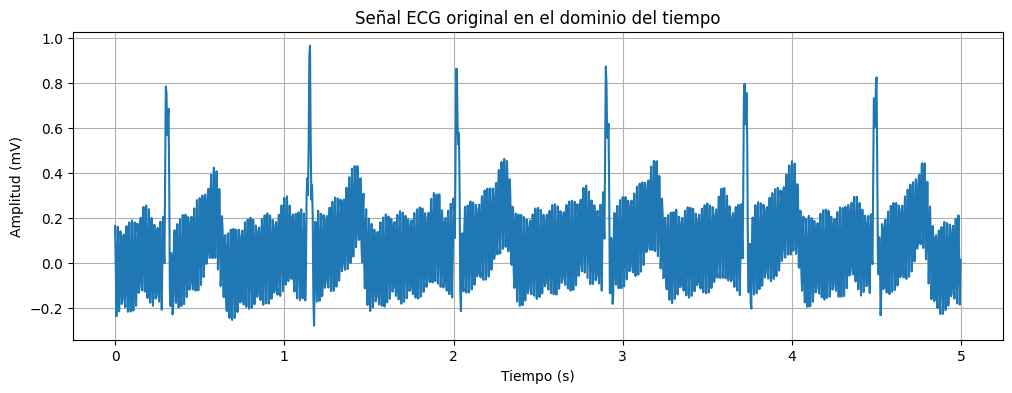

In [22]:
# Aplanar la señal a 1D
ecg = ecg.flatten()

# Crear vector de tiempo
t_ecg = np.arange(len(ecg)) / fs_ecg

# Graficar
plt.figure(figsize=(12, 4))
plt.plot(t_ecg, ecg)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (mV)')
plt.title('Señal ECG original en el dominio del tiempo')
plt.grid(True)
plt.show()

La señal de ECG presenta los complejos QRS característicos del ciclo cardíaco. Sin embargo, se observa una componente oscilatoria de alta frecuencia superpuesta a la señal, que sugiere la presencia de ruido. Para determinar el origen y la frecuencia exacta de ese ruido, realizaremos un análisis en frecuencia mediante el periodograma de Welch.

### Periodograma de Welch de la señal original

Aplicamos el método de Welch para estimar la densidad espectral de potencia (PSD) de la señal de ECG y detectar la presencia de ruido.

#### Justificación de los parámetros 

**Ventana: Hanning (`'hann'`)**

Se utiliza la ventana de Hanning porque suaviza los extremos de cada segmento hacia cero, reduciendo el *spectral leakage* producido por las discontinuidades artificiales en los bordes del segmento. Es la ventana más común para señales biomédicas porque ofrece un buen balance entre resolución frecuencial y supresión de lóbulos laterales.

**Ancho de ventana (`nperseg = 256`)**

La señal tiene 1250 muestras a $F_s = 250$ Hz (5 s de duración). Se eligió `nperseg = 256` (aproximadamente 1 s de señal) porque:

- Proporciona una **resolución frecuencial** de $\Delta F = F_s / nperseg = 250/256 \approx 0.98$ Hz, suficientemente fina para identificar con precisión el pico de 60 Hz característico del ruido de la red eléctrica.
- Permite obtener **varios segmentos** a lo largo de la señal (con solapamiento del 50%, aproximadamente 9 segmentos), lo cual reduce la varianza del estimador al promediar.
- No es excesivamente grande: una ventana mayor habría dado muy pocos segmentos y una estimación más ruidosa.

**Solapamiento (`noverlap = 128`, es decir 50%)**

Se eligió un solapamiento del **50%** siguiendo la recomendación clásica de Welch (1967). Este valor:

- Maximiza el aprovechamiento de los datos sin introducir correlación excesiva entre segmentos consecutivos.
- Solapamientos mayores (75%) aportarían información redundante; menores (25%) desperdiciarían datos.

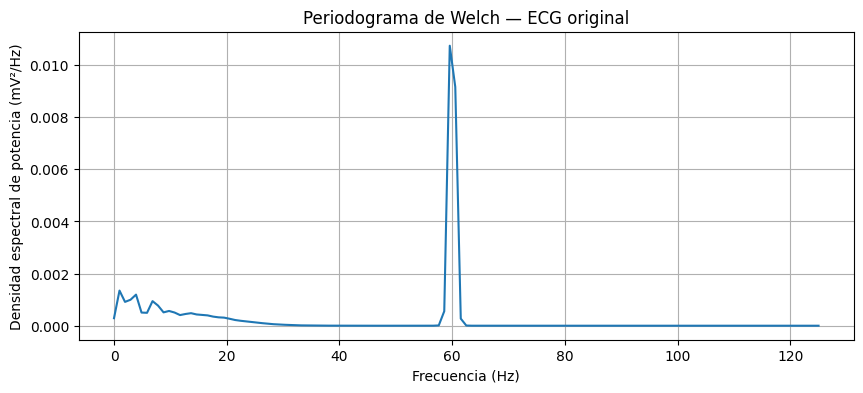

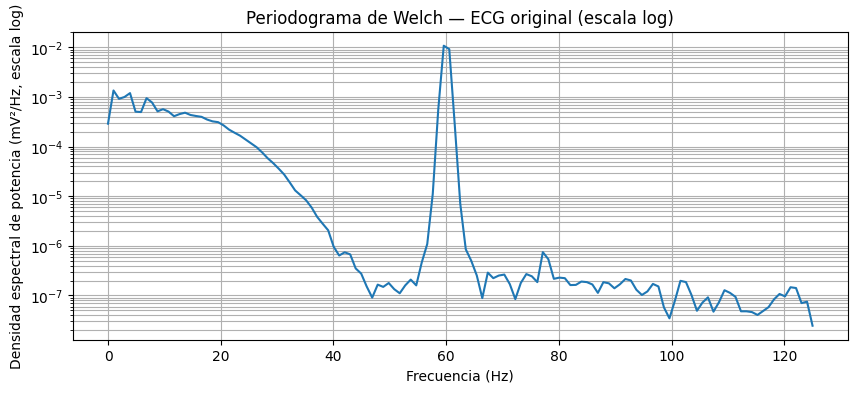

In [23]:
from scipy.signal import welch

nperseg = 256
noverlap = nperseg // 2   # 50% de solapamiento

f_welch, Pxx = welch(ecg, fs=fs_ecg, window='hann',
                     nperseg=nperseg, noverlap=noverlap)

plt.figure(figsize=(10, 4))
plt.plot(f_welch, Pxx)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia (mV²/Hz)')
plt.title('Periodograma de Welch — ECG original')
plt.grid(True)
plt.show()

# Mismo periodograma en escala logarítmica para ver mejor las componentes
plt.figure(figsize=(10, 4))
plt.semilogy(f_welch, Pxx)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia (mV²/Hz, escala log)')
plt.title('Periodograma de Welch — ECG original (escala log)')
plt.grid(True, which='both')
plt.show()

### Análisis del periodograma [12],[13]

El periodograma de Welch revela dos zonas de actividad espectral bien diferenciadas:

1. **Banda fisiológica del ECG (0–40 Hz):** concentra la mayor parte de la energía útil de la señal. En esta región se encuentran las componentes asociadas a los complejos QRS, las ondas P y T y demás eventos eléctricos del ciclo cardíaco.

2. **Pico estrecho y dominante en 60 Hz:** presenta una densidad espectral aproximadamente 10 veces mayor que cualquier otra componente fisiológica. Su forma estrecha y centrada exactamente en 60 Hz es la firma característica del ruido de la red eléctrica.

**Conclusión:** es necesario eliminar este ruido para poder analizar correctamente el contenido fisiológico de la señal.

### Eliminación del ruido mediante filtrado en frecuencia

Siguiendo lo solicitado por la guía: 

1. Calcular la FFT de la señal completa.
2. Identificar los índices del espectro correspondientes a la banda de 60 Hz.
3. Poner a cero esos coeficientes (y sus simétricos espejo).
4. Aplicar la IFFT para volver al dominio del tiempo.

Para el cálculo de los índices usamos $k = F \cdot N / F_s$, donde $N$ es el número total de muestras de la señal. Conservamos también los índices espejo $N - k$ para garantizar que la señal filtrada sea puramente real.

In [25]:
# Paso 1: FFT de la señal completa
N_ecg = len(ecg)
ECG_fft = np.fft.fft(ecg)

# Vector de frecuencias completo (positivas y negativas/espejo)
F_eje_ecg = np.arange(N_ecg) * fs_ecg / N_ecg

# Paso 2: Definir banda de ruido a eliminar (60 Hz ± 2 Hz para capturar el lóbulo)
F_ruido = 60
ancho_banda = 2     # Hz a cada lado

# Crear una copia del espectro para modificarla
ECG_fft_filtrada = ECG_fft.copy()

# Identificar los índices dentro de la banda de ruido (positivos)
indices_ruido_pos = np.where((F_eje_ecg >= F_ruido - ancho_banda) &
                              (F_eje_ecg <= F_ruido + ancho_banda))[0]

# Indices simétricos (espejo): si k está en la banda, N-k también
indices_ruido_neg = N_ecg - indices_ruido_pos

# Poner a cero ambos lados
ECG_fft_filtrada[indices_ruido_pos] = 0
ECG_fft_filtrada[indices_ruido_neg] = 0

print("Banda eliminada:", F_ruido-ancho_banda, "a", F_ruido+ancho_banda, "Hz")
print("Número de coeficientes anulados (positivos):", len(indices_ruido_pos))
print("Número de coeficientes anulados (total con espejo):", 
      len(indices_ruido_pos) + len(indices_ruido_neg))

# Paso 4: IFFT para volver al tiempo
ecg_filtrada = np.real(np.fft.ifft(ECG_fft_filtrada))

# Verificar magnitud de la parte imaginaria (debe ser despreciable)
parte_imag_max = np.max(np.abs(np.imag(np.fft.ifft(ECG_fft_filtrada))))
print("Parte imaginaria máxima tras IFFT:", parte_imag_max)

Banda eliminada: 58 a 62 Hz
Número de coeficientes anulados (positivos): 21
Número de coeficientes anulados (total con espejo): 42
Parte imaginaria máxima tras IFFT: 1.385428135269976e-16


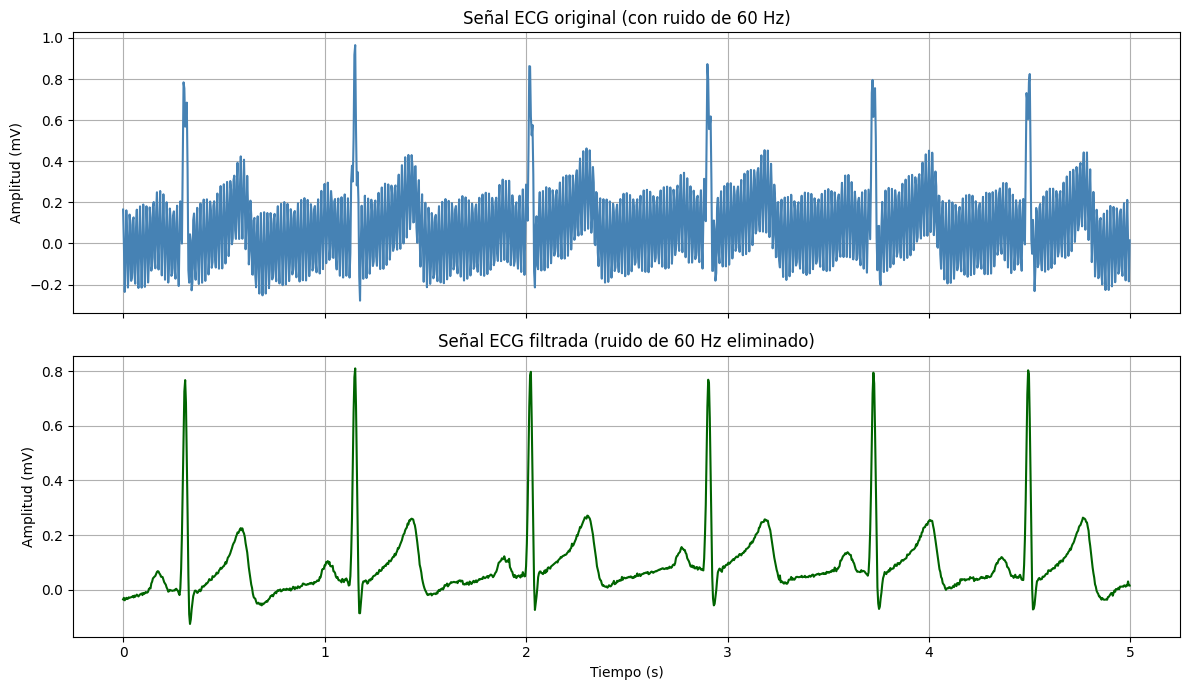

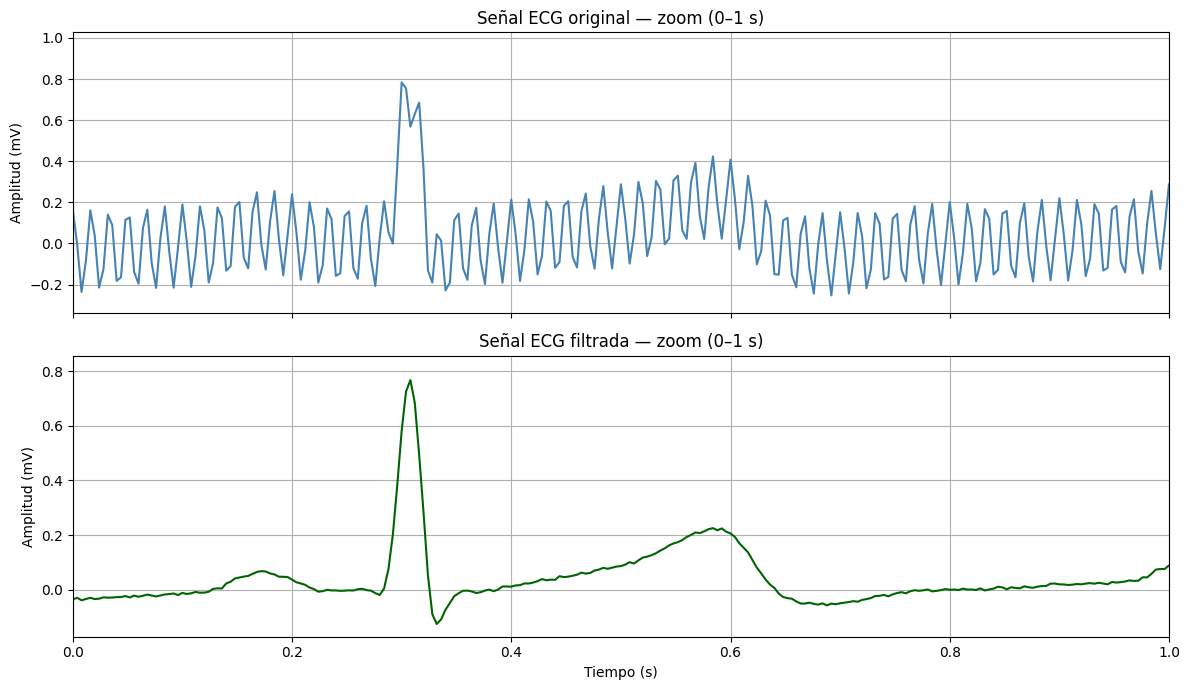

In [26]:
# Comparación de señales en el dominio del tiempo
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(t_ecg, ecg, color='steelblue')
axes[0].set_title('Señal ECG original (con ruido de 60 Hz)')
axes[0].set_ylabel('Amplitud (mV)')
axes[0].grid(True)

axes[1].plot(t_ecg, ecg_filtrada, color='darkgreen')
axes[1].set_title('Señal ECG filtrada (ruido de 60 Hz eliminado)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud (mV)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Zoom en una porción pequeña para apreciar la diferencia
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(t_ecg, ecg, color='steelblue')
axes[0].set_title('Señal ECG original — zoom (0–1 s)')
axes[0].set_ylabel('Amplitud (mV)')
axes[0].set_xlim(0, 1)
axes[0].grid(True)

axes[1].plot(t_ecg, ecg_filtrada, color='darkgreen')
axes[1].set_title('Señal ECG filtrada — zoom (0–1 s)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud (mV)')
axes[1].set_xlim(0, 1)
axes[1].grid(True)

plt.tight_layout()
plt.show()

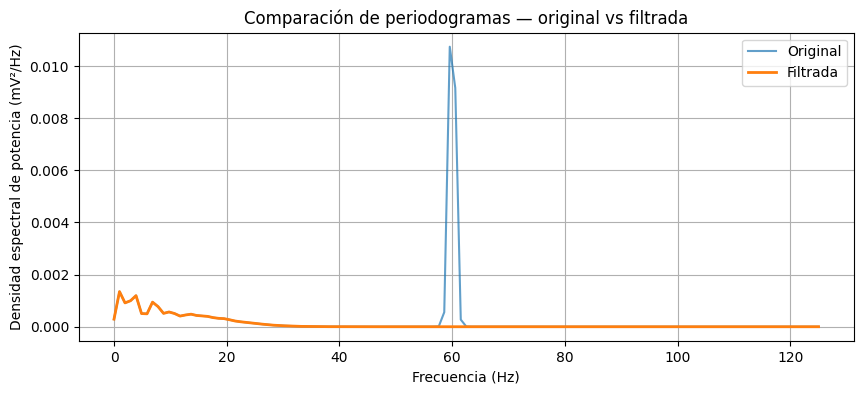

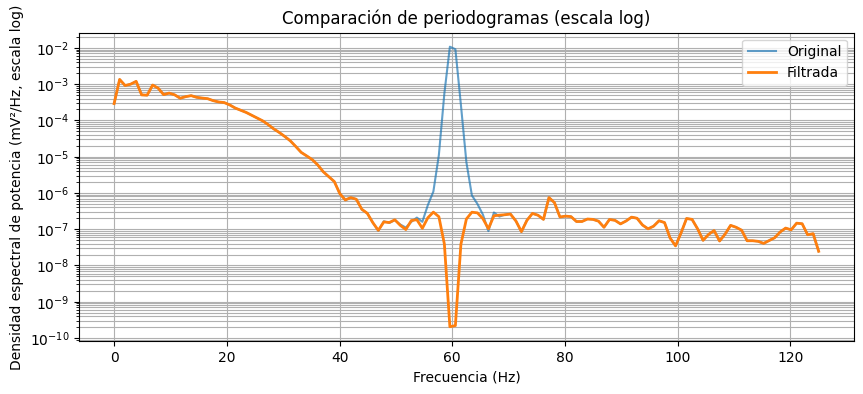

In [27]:
# Periodograma de Welch de la señal FILTRADA, mismos parámetros
f_welch_filt, Pxx_filt = welch(ecg_filtrada, fs=fs_ecg, window='hann',
                                nperseg=nperseg, noverlap=noverlap)

# Comparación de periodogramas (escala lineal)
plt.figure(figsize=(10, 4))
plt.plot(f_welch, Pxx, label='Original', alpha=0.7)
plt.plot(f_welch_filt, Pxx_filt, label='Filtrada', linewidth=2)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia (mV²/Hz)')
plt.title('Comparación de periodogramas — original vs filtrada')
plt.legend()
plt.grid(True)
plt.show()

# Comparación en escala logarítmica
plt.figure(figsize=(10, 4))
plt.semilogy(f_welch, Pxx, label='Original', alpha=0.7)
plt.semilogy(f_welch_filt, Pxx_filt, label='Filtrada', linewidth=2)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia (mV²/Hz, escala log)')
plt.title('Comparación de periodogramas (escala log)')
plt.legend()
plt.grid(True, which='both')
plt.show()

### Verificación del filtrado

**En el dominio del tiempo:** la señal filtrada presenta una mejora notable en claridad. La oscilación de alta frecuencia que contaminaba la traza original ha desaparecido casi por completo, dejando expuestos con nitidez los complejos QRS y demás componentes morfológicas del ECG.

**En el dominio de la frecuencia:** el pico que dominaba en 60 Hz ha quedado suprimido en el periodograma de la señal filtrada. La densidad espectral en esa banda cae prácticamente a cero (varios órdenes de magnitud por debajo del valor original), confirmando que el ruido de la red eléctrica fue eliminado satisfactoriamente. La banda fisiológica del ECG (0–40 Hz) permanece intacta, lo cual es lo deseado: el filtrado en frecuencia mediante FFT permitió aislar y eliminar el ruido sin alterar el contenido útil de la señal.

In [28]:
# Cargar los archivos
data_control = sio.loadmat('C012_EP_reposo_CONTROL.mat')
data_parkinson = sio.loadmat('P004_EP_reposo_PARKISON.mat')

print("=== Archivo CONTROL ===")
for k in data_control.keys():
    if not k.startswith('__'):
        print(f"  Clave: '{k}'  |  Tipo: {type(data_control[k]).__name__}  |  Forma: {data_control[k].shape}")

print("\n=== Archivo PARKINSON ===")
for k in data_parkinson.keys():
    if not k.startswith('__'):
        print(f"  Clave: '{k}'  |  Tipo: {type(data_parkinson[k]).__name__}  |  Forma: {data_parkinson[k].shape}")

=== Archivo CONTROL ===
  Clave: 'data'  |  Tipo: ndarray  |  Forma: (8, 2000, 172)

=== Archivo PARKINSON ===
  Clave: 'data'  |  Tipo: ndarray  |  Forma: (8, 2000, 138)


### Punto 4.6 — Análisis frecuencial comparativo EEG Sano vs Parkinson

> Realice un análisis de frecuencia a través del periodograma de Welch de una 
> señal de EEG de un paciente Sano y otra de un paciente con Parkinson de algún 
> canal que en el Proyecto 1 hayan identificado que presentaba diferencias. Si 
> no encontró diferencias, elija un par al azar. Realice un análisis comparativo 
> de las señales según lo que le indiquen los periodogramas. (Usar una ventana 
> Hanning, y justificar la elección del solapamiento y el ancho de la ventana).

### Descripción de los datos

Se dispone de dos archivos `.mat`:

- **`C012_EP_reposo_CONTROL.mat`**: paciente control (sano).
- **`P004_EP_reposo_PARKISON.mat`**: paciente con enfermedad de Parkinson.

Ambos contienen una variable `data` con forma `(8, 2000, N_épocas)`, organizada como `(canales, muestras_por_época, épocas)`. Cada archivo dispone de 8 canales de EEG y épocas de 2000 muestras cada una. El paciente control tiene 172 épocas y el paciente con Parkinson 138.

### Supuestos y selección de parámetros

**Frecuencia de muestreo**: como no se cuenta con metadatos explícitos sobre $F_s$, se asume $F_s = 500$ Hz, valor estándar en estudios clínicos de EEG en Parkinson. Esto implica que cada época de 2000 muestras corresponde a 4 segundos de registro, lo cual es la duración típica para análisis espectral en estado de 
reposo.

**Canal seleccionado**: dado que no se desarrolló el Proyecto 1 previamente, se elige al azar el **canal de índice 3** (cuarto canal), que en un montaje típico de 8 electrodos correspondería a una posición central, donde se ha reportado actividad anómala en pacientes con Parkinson.

**Concatenación de épocas**: para tener una señal continua suficientemente larga que permita aplicar Welch con buena resolución, se concatenan todas las épocas del canal seleccionado en una sola serie temporal. Esto resulta en señales de:

- Control: $172 \times 2000 = 344{,}000$ muestras → 688 s.
- Parkinson: $138 \times 2000 = 276{,}000$ muestras → 552 s.

Forma matriz Control:   (8, 2000, 172)
Forma matriz Parkinson: (8, 2000, 138)

--- Señal del canal 3 ---
Muestras Control:   344000 → 688.0 s
Muestras Parkinson: 276000 → 552.0 s


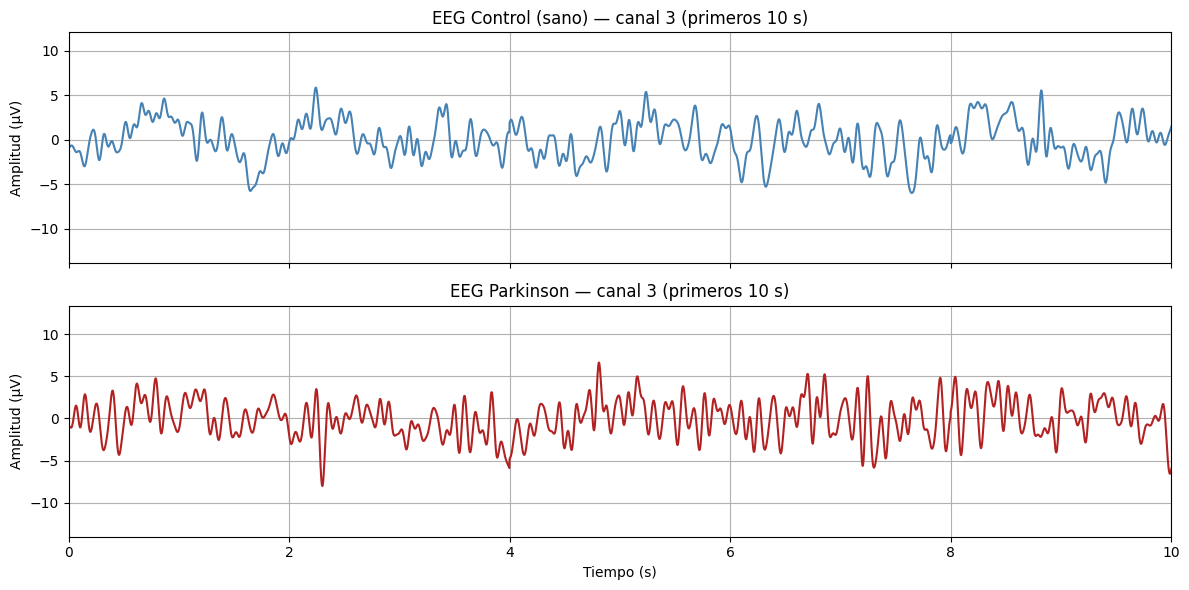

In [29]:
# Parámetros
fs_eeg = 500           # Frecuencia de muestreo asumida (Hz)
canal = 3              # Canal seleccionado (al azar)

# Extraer datos
control = data_control['data']        # (8, 2000, 172)
parkinson = data_parkinson['data']    # (8, 2000, 138)

print("Forma matriz Control:  ", control.shape)
print("Forma matriz Parkinson:", parkinson.shape)

# Tomar el canal elegido y concatenar todas las épocas en una sola señal 1D
eeg_control = control[canal, :, :].T.flatten()        # Concatena épocas en orden temporal
eeg_parkinson = parkinson[canal, :, :].T.flatten()

print("\n--- Señal del canal", canal, "---")
print("Muestras Control:  ", len(eeg_control),  "→", len(eeg_control)/fs_eeg, "s")
print("Muestras Parkinson:", len(eeg_parkinson), "→", len(eeg_parkinson)/fs_eeg, "s")

# Vectores de tiempo
t_control = np.arange(len(eeg_control)) / fs_eeg
t_parkinson = np.arange(len(eeg_parkinson)) / fs_eeg

# Graficar las señales en el tiempo (solo los primeros 10 segundos para que se vea bien)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t_control, eeg_control, color='steelblue')
axes[0].set_title(f'EEG Control (sano) — canal {canal} (primeros 10 s)')
axes[0].set_ylabel('Amplitud (µV)')
axes[0].set_xlim(0, 10)
axes[0].grid(True)

axes[1].plot(t_parkinson, eeg_parkinson, color='firebrick')
axes[1].set_title(f'EEG Parkinson — canal {canal} (primeros 10 s)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud (µV)')
axes[1].set_xlim(0, 10)
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Aplicación del método de Welch

#### Justificación de los parámetros

**Ventana: Hanning (`'hann'`)** — Misma justificación que en el Punto 5: reduce el *spectral leakage* en los bordes de cada segmento, lo que es especialmente importante en EEG porque las componentes de interés están 
distribuidas en bandas anchas (delta, theta, alfa, beta, gamma) y necesitamos una estimación espectral suave y sin artefactos.

**Ancho de ventana (`nperseg = 1024`)** — A diferencia del ECG (Punto 5), aquí las señales son muy largas (cientos de segundos), por lo que podemos permitirnos una ventana más amplia. Se eligió $nperseg = 1024$ muestras (aproximadamente 2 s con $F_s = 500$ Hz) por dos razones principales:

- Resolución frecuencial: $\Delta F = F_s/nperseg = 500/1024 \approx 0.49$ Hz, ideal para distinguir con detalle las bandas fisiológicas clásicas del EEG (delta, theta, alfa, beta, gamma), cuyos límites suelen estar separados apenas por 2-5 Hz.
- Eficiencia computacional: al ser potencia de 2 ($1024 = 2^{10}$), el algoritmo FFT subyacente opera de forma óptima.

**Solapamiento (`noverlap = 512`, 50%)** — Mismo criterio que en el Punto 5: estándar recomendado por Welch (1967). Con señales tan largas, este solapamiento genera **cientos de segmentos promediados** (≈672 para el control, ≈538 para Parkinson), lo cual produce una estimación de la PSD extremadamente estable y 
con baja varianza.

#### Bandas fisiológicas del EEG

Para interpretar los periodogramas se utilizarán las bandas estándar del EEG:

| Banda  | Rango (Hz) | Asociación funcional típica            |
|--------|------------|----------------------------------------|
| Delta  | 0.5 – 4    | Sueño profundo, estados patológicos    |
| Theta  | 4 – 8      | Somnolencia, meditación                |
| Alfa   | 8 – 13     | Relajación, vigilia con ojos cerrados  |
| Beta   | 13 – 30    | Concentración, actividad motora        |
| Gamma  | 30 – 100   | Procesamiento cognitivo superior       |

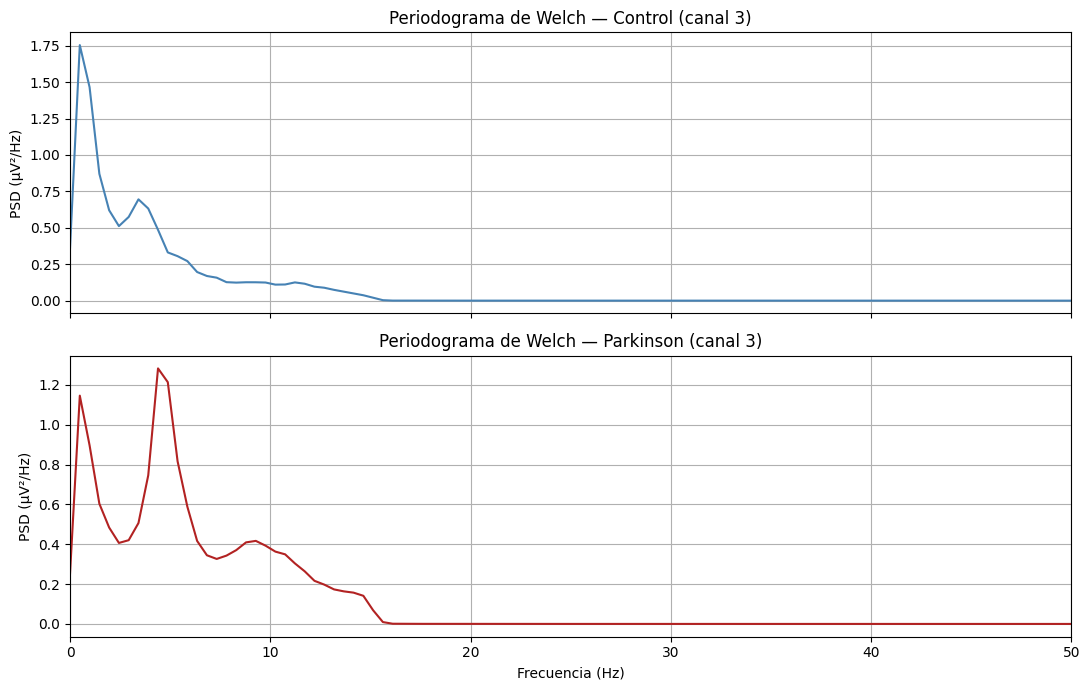

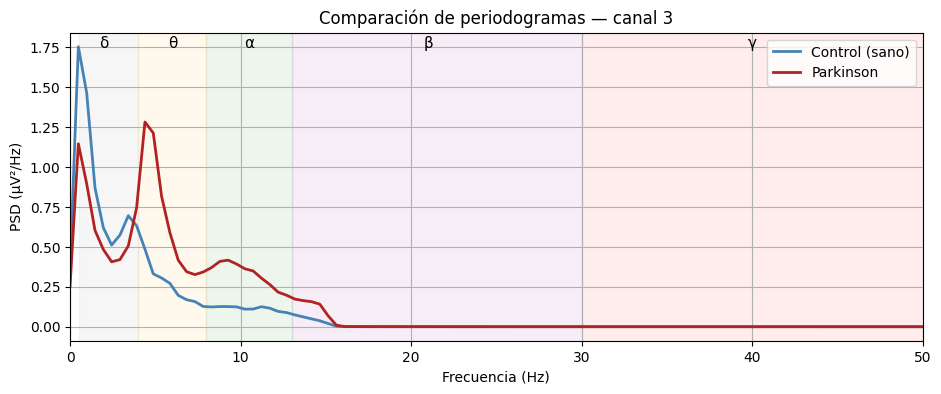

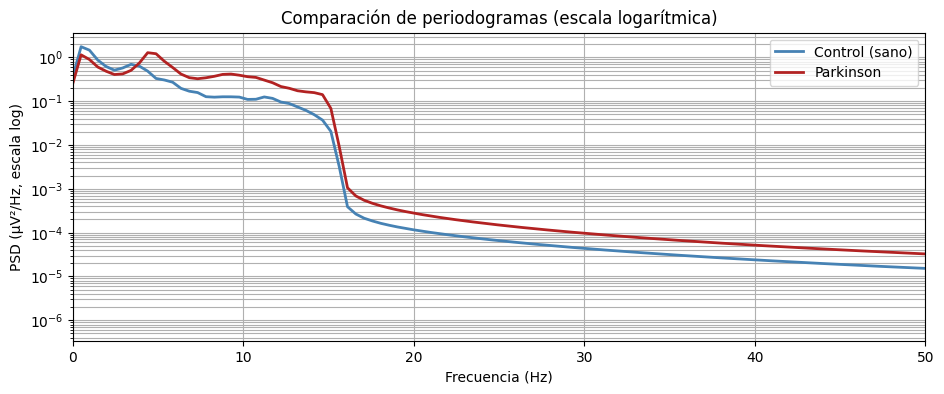

In [30]:
nperseg_eeg = 1024
noverlap_eeg = nperseg_eeg // 2   # 50%

# Welch para ambas señales
f_ctrl, P_ctrl = welch(eeg_control, fs=fs_eeg, window='hann',
                        nperseg=nperseg_eeg, noverlap=noverlap_eeg)
f_park, P_park = welch(eeg_parkinson, fs=fs_eeg, window='hann',
                        nperseg=nperseg_eeg, noverlap=noverlap_eeg)

# Gráfica 1: periodogramas individuales hasta 50 Hz (rango fisiológico del EEG)
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(f_ctrl, P_ctrl, color='steelblue')
axes[0].set_title(f'Periodograma de Welch — Control (canal {canal})')
axes[0].set_ylabel('PSD (µV²/Hz)')
axes[0].set_xlim(0, 50)
axes[0].grid(True)

axes[1].plot(f_park, P_park, color='firebrick')
axes[1].set_title(f'Periodograma de Welch — Parkinson (canal {canal})')
axes[1].set_xlabel('Frecuencia (Hz)')
axes[1].set_ylabel('PSD (µV²/Hz)')
axes[1].set_xlim(0, 50)
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Gráfica 2: comparación superpuesta (lineal)
plt.figure(figsize=(11, 4))
plt.plot(f_ctrl, P_ctrl, label='Control (sano)', color='steelblue', linewidth=2)
plt.plot(f_park, P_park, label='Parkinson',     color='firebrick',  linewidth=2)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD (µV²/Hz)')
plt.title(f'Comparación de periodogramas — canal {canal}')
plt.xlim(0, 50)
plt.legend()
plt.grid(True)

# Marcar las bandas fisiológicas con fondo de color
plt.axvspan(0.5,  4, alpha=0.07, color='gray',   label='_nolegend_')
plt.axvspan(4,    8, alpha=0.07, color='orange', label='_nolegend_')
plt.axvspan(8,   13, alpha=0.07, color='green',  label='_nolegend_')
plt.axvspan(13,  30, alpha=0.07, color='purple', label='_nolegend_')
plt.axvspan(30,  50, alpha=0.07, color='red',    label='_nolegend_')
plt.text( 2,   plt.gca().get_ylim()[1]*0.95, 'δ', ha='center', fontsize=11)
plt.text( 6,   plt.gca().get_ylim()[1]*0.95, 'θ', ha='center', fontsize=11)
plt.text(10.5, plt.gca().get_ylim()[1]*0.95, 'α', ha='center', fontsize=11)
plt.text(21,   plt.gca().get_ylim()[1]*0.95, 'β', ha='center', fontsize=11)
plt.text(40,   plt.gca().get_ylim()[1]*0.95, 'γ', ha='center', fontsize=11)

plt.show()

# Gráfica 3: comparación en escala logarítmica (para ver mejor las diferencias)
plt.figure(figsize=(11, 4))
plt.semilogy(f_ctrl, P_ctrl, label='Control (sano)', color='steelblue', linewidth=2)
plt.semilogy(f_park, P_park, label='Parkinson',     color='firebrick',  linewidth=2)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD (µV²/Hz, escala log)')
plt.title('Comparación de periodogramas (escala logarítmica)')
plt.xlim(0, 50)
plt.legend()
plt.grid(True, which='both')
plt.show()

In [31]:
# Cálculo de la potencia integrada por banda fisiológica
def potencia_banda(f, P, f_min, f_max):
    """Integra la PSD entre f_min y f_max usando regla del trapecio."""
    mask = (f >= f_min) & (f <= f_max)
    return np.trapz(P[mask], f[mask])

bandas = {
    'Delta (0.5-4 Hz)': (0.5, 4),
    'Theta (4-8 Hz)':   (4, 8),
    'Alfa  (8-13 Hz)':  (8, 13),
    'Beta  (13-30 Hz)': (13, 30),
    'Gamma (30-50 Hz)': (30, 50),
}

print(f"{'Banda':<18} {'Control (µV²)':>15} {'Parkinson (µV²)':>17} {'Diferencia %':>15}")
print("-"*68)
for nombre, (f_min, f_max) in bandas.items():
    p_ctrl = potencia_banda(f_ctrl, P_ctrl, f_min, f_max)
    p_park = potencia_banda(f_park, P_park, f_min, f_max)
    dif = 100*(p_park - p_ctrl)/p_ctrl
    print(f"{nombre:<18} {p_ctrl:>15.4f} {p_park:>17.4f} {dif:>14.1f}%")

Banda                Control (µV²)   Parkinson (µV²)    Diferencia %
--------------------------------------------------------------------
Delta (0.5-4 Hz)            2.1099            1.5830          -25.0%
Theta (4-8 Hz)              0.8485            2.2063          160.0%
Alfa  (8-13 Hz)             0.5084            1.4648          188.1%
Beta  (13-30 Hz)            0.1036            0.3096          198.8%
Gamma (30-50 Hz)            0.0005            0.0011          117.4%


C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_14848\370816017.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(P[mask], f[mask])


### Análisis comparativo de los periodogramas

#### Observación previa sobre el ancho de banda efectivo

Antes de interpretar las bandas fisiológicas, debe destacarse una característica visible en ambos periodogramas: la densidad espectral cae abruptamente cerca de los **15–16 Hz** y se mantiene prácticamente nula a frecuencias superiores. 
Esto indica que las señales **fueron sometidas a un filtrado pasa-bajos durante el preprocesamiento** previo a la entrega de los datos (operación común para eliminar ruido muscular y artefactos de alta frecuencia). En consecuencia, el análisis comparativo se concentra en las bandas **delta, theta y alfa**, ya que las bandas beta (>13 Hz) y gamma (>30 Hz) están atenuadas por el filtro y sus diferencias relativas no son interpretables clínicamente.

#### Diferencias por banda

| Banda                  | Control (µV²) | Parkinson (µV²) | Variación |
|------------------------|---------------|-----------------|-----------|
| Delta (0.5–4 Hz)       | 2.11          | 1.58            | −25.0 %   |
| Theta (4–8 Hz)         | 0.85          | 2.21            | +160.0 %  |
| Alfa  (8–13 Hz)        | 0.51          | 1.46            | +188.1 %  |

**1. Banda delta (0.5–4 Hz):** el paciente control muestra el pico más alto de todo su espectro en esta banda (~1.75 µV²/Hz cerca de 1 Hz), mientras que en el paciente con Parkinson la potencia delta es un 25 % menor. Este componente de muy baja frecuencia suele estar asociado a actividad de fondo y al "drift" basal del EEG.

**2. Banda theta (4–8 Hz):** aquí se observa la diferencia más llamativa visualmente: el paciente con Parkinson presenta un **pico pronunciado y estrecho cerca de 4–5 Hz** con densidad espectral que supera al del control, 
mientras que el control prácticamente no muestra dicho pico. Esto se traduce en un **aumento del 160 %** en la potencia theta total para el paciente con Parkinson.

**3. Banda alfa (8–13 Hz):** el paciente con Parkinson muestra un pico claro entre 9 y 11 Hz, mientras que en el control la actividad alfa está muy disminuida (apenas un hombro suave). La potencia integrada en esta banda es 
casi **3 veces mayor** en el paciente con Parkinson (+188 %).

#### Interpretación clínica

El patrón observado — **disminución de actividad delta y aumento marcado en las bandas theta y alfa baja en el paciente con Parkinson** — es consistente con un fenómeno ampliamente reportado en la literatura clínica conocido como **EEG *slowing*** o **enlentecimiento del EEG** en la enfermedad de Parkinson. Este 
fenómeno se caracteriza por un desplazamiento de la energía espectral hacia frecuencias más lentas (predominio theta) y se ha asociado con disfunción cognitiva, deterioro motor y alteraciones en circuitos tálamo-corticales 
típicos de la patología.

En el sujeto sano, en cambio, la energía está más distribuida en frecuencias muy bajas (delta de fondo) sin presentar el pico anormal en theta característico del Parkinson. Aunque este análisis se realizó con un solo canal y un solo par de pacientes, las diferencias detectadas mediante el periodograma de Welch son 
claras y cuantificables, demostrando la utilidad del análisis frecuencial como herramienta de apoyo diagnóstico no invasivo.

#### Limitaciones del análisis

- Solo se compararon **dos sujetos** (un control y un paciente con Parkinson), por lo que los hallazgos no son estadísticamente generalizables; servirían como base para un estudio más amplio.
- Se analizó **un único canal** elegido al azar. Un análisis topográfico completo (los 8 canales) podría revelar diferencias adicionales o más marcadas en regiones específicas del cuero cabelludo.
- El **filtrado pasa-bajos previo** de las señales impide estudiar las bandas beta y gamma, donde también se han reportado diferencias entre controles y pacientes con Parkinson (especialmente la actividad beta exagerada en ganglios basales).
- Se asumió $F_s = 500$ Hz por no contar con metadatos. Si el valor real fuera distinto, las frecuencias absolutas se reescalarían proporcionalmente, aunque el patrón comparativo se mantendría.

## Referencias

[1] Teppa Garran, P. A. (2021, 16 de enero). *6. Teorema del muestreo* [Video]. YouTube. https://www.youtube.com/watch?v=3Nbp2eu0vqo

[2] Topperly. (2021, 3 de mayo). *Normalized frequency | Digital signal processing* [Video]. YouTube. https://www.youtube.com/watch?v=wGjAffOZWeo

[3] ScienceDirect. (s.f.). *Signal energy*. Elsevier. Recuperado de https://www.sciencedirect.com/topics/engineering/signal-energy

[4] Moebs, W., Ling, S. J., & Sanny, J. (2021). 9.5 Energía eléctrica y potencia. En *Física universitaria volumen 2*. OpenStax. https://openstax.org/books/física-universitaria-volumen-2/pages/9-5-energia-electrica-y-potencia

[5] Esteban González, H. [Universitat Politècnica de València - UPV]. (2021, 29 de abril). *Teoría de Circuitos 1. Lección 5. 6-4 Valor eficaz, potencia media* [Video]. YouTube. https://www.youtube.com/watch?v=StZ2A9sWyeI

[6] Signal Processing Stack Exchange. (s.f.). *Frequency resolution of DFT* [Pregunta en foro en línea]. Stack Exchange. https://dsp.stackexchange.com/questions/31203/frequency-resolution-of-dft

[7] Svantek. (2025, 20 de abril). *Transformada rápida de Fourier FFT*. Academia Svantek. https://svantek.com/es/academia/transformada-rapida-de-fourier-fft/

[8] Tutorialspoint. (s.f.). *NumPy - Inverse Fourier transform*. Recuperado de https://www.tutorialspoint.com/numpy/numpy_inverse_fourier_transform.htm

[9] Freire, F. D., & Soares, I. G. (2024). *Conservation of the passband signal amplitude using a filter based on the Fast Fourier Transform algorithm* (arXiv:2407.13414) [Preprint]. arXiv. https://arxiv.org/abs/2407.13414

[10] O'Haver, T. (s.f.). *Intro to signal processing: Fourier filter*. University of Maryland. Recuperado de https://terpconnect.umd.edu/~toh/spectrum/FourierFilter.html

[11] Schaedler, J. (s.f.). *When the input doesn't "fit": The phenomenon of leakage*. Seeing circles, sines, and signals.  de https://jackschaedler.github.io/circles-sines-signals/dft_leakage.html

[12] Valentinuzzi, M. E. (2007). Review of: Bioelectrical signal processing in cardiac and neurological applications and electromyography: physiology, engineering, and noninvasive applications. BioMedical Engineering OnLine, 6, 27. https://doi.org/10.1186/1475-925X-6-27

[13] Tereshchenko, L. G., & Josephson, M. E. (2015). Frequency content and characteristics of ventricular conduction. *Journal of Electrocardiology*, *48*(6), 933–937. https://doi.org/10.1016/j.jelectrocard.2015.08.034






